# Imports

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

# Datasets loading

In [111]:
url1 = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
df = pd.read_csv(url1) #training models

- HUFL, HULL: High-usage frequency limits (upper/lower)
- MUFL, MULL: Medium-usage frequency limits (upper/lower)
- LUFL, LULL:
- OT: Operational Temperature (target variable)

# Analyse du jeu de donnée ETTH1

In [184]:
target_variable = "OT"

timestamp_col = "date"

num_periods_output = 1 #horizon
num_periods_input = 168 #w

test_size = 24*30*4 + num_periods_input

hyperparameters = {
    "selected_features" : [target_variable]
    }

In [185]:
# df[timestamp_col] = pd.to_datetime(df[timestamp_col])
# df.index = pd.to_datetime(df[timestamp_col])
df = df[[target_variable]]
df.sort_values(by=timestamp_col, ascending=True, inplace=True)

In [186]:
training_data = df.iloc[:-test_size]
training_data

,OT
date,
2016-07-01 00:00:00,30.531000
2016-07-01 01:00:00,27.787001
2016-07-01 02:00:00,27.787001
2016-07-01 03:00:00,25.044001
2016-07-01 04:00:00,21.948000
...,...
2018-02-19 15:00:00,2.955000
2018-02-19 16:00:00,2.884000
2018-02-19 17:00:00,3.025000


In [187]:
test_data = df.iloc[-test_size:]
test_data

,OT
date,
2018-02-19 20:00:00,3.306
2018-02-19 21:00:00,3.658
2018-02-19 22:00:00,3.447
2018-02-19 23:00:00,3.728
2018-02-20 00:00:00,3.799
...,...
2018-06-26 15:00:00,10.904
2018-06-26 16:00:00,11.044
2018-06-26 17:00:00,10.271


In [188]:
#https://github.com/KasperGroesLudvigsen/xgboost_time_series/tree/main by KasperGroesLudvigsen
# step_sizes modified to match the paper associated

def get_indices_entire_sequence(data: pd.DataFrame, window_size: int, step_size: int) -> list:
        """
        Produce all the start and end index positions that is needed to produce
        the sub-sequences. 
        Returns a list of tuples. Each tuple is (start_idx, end_idx) of a sub-
        sequence. These tuples should be used to slice the dataset into sub-
        sequences. These sub-sequences should then be passed into a function
        that slices them into input and target sequences. 
        
        Args:
            data (pd.DataFrame): Partitioned data set, e.g. training data

            window_size (int): The desired length of each sub-sequence. Should be
                               (input_sequence_length + num_periods_output)
                               E.g. if you want the model to consider the past 100
                               time steps in order to predict the future 50 
                               time steps, window_size = 100+50 = 150
            step_size (int): Size of each step as the data sequence is traversed 
                             by the moving window.
                             If 1, the first sub-sequence will be [0:window_size], 
                             and the next will be [1:window_size].
        Return:
            indices: a list of tuples
        """
        stop_position = len(data)-1 # -1 because of 0 indexing
        # Start the first sub-sequence at index position 0
        subseq_first_idx = 0
        subseq_last_idx = window_size

        indices = []
        while subseq_last_idx <= stop_position:
            indices.append((subseq_first_idx, subseq_last_idx))
            subseq_first_idx += step_size
            subseq_last_idx += step_size
        return indices


def get_xgboost_x_y(indices: list, data: np.array, num_periods_output, input_seq_len: int):
    """
    Args:
        indices: List of index positions at which data should be sliced
        data: A univariate time series
        num_periods_output: The forecasting horizon, m
        input_seq_len: The length of the model input, n

    Output: 
        all_x: np.array of shape (number of instances, input seq len)
        all_y: np.array of shape (number of instances, target seq len)

    """
    print("Preparing data..")

    # Loop over list of training indices
    for i, idx in enumerate(indices):
        # Slice data into instance of length input length + target length
        data_instance = data[idx[0]:idx[1]]
        x = data_instance[0:input_seq_len]
        assert len(x) == input_seq_len
        y = data_instance[input_seq_len:input_seq_len+num_periods_output]
        
        # Create all_y and all_x objects in first loop iteration
        if i == 0:
            all_y = y.reshape(1, -1)
            all_x = x.reshape(1, -1)
        else:
            all_y = np.concatenate((all_y, y.reshape(1, -1)), axis=0)
            all_x = np.concatenate((all_x, x.reshape(1, -1)), axis=0)

    print("Finished preparing data!")
    return all_x, all_y

# ---------------------------------------------------------------

# Create indices. Must be passed to function that creates (X,Y) pairs so that
# it knows where to slice the data
training_indices = get_indices_entire_sequence(
    data=training_data, 
    window_size=num_periods_input+num_periods_output, 
    step_size = 1 # Dans le papier, on incrémente le start_train par 1
    )

# Obtain (X,Y) pairs of training data
x_train, y_train = get_xgboost_x_y(
    indices=training_indices, 
    data=training_data[hyperparameters["selected_features"]].to_numpy(),
    num_periods_output=num_periods_output,
    input_seq_len=num_periods_input
    )

test_indices = get_indices_entire_sequence(
    data=test_data, 
    window_size=num_periods_input+num_periods_output, 
    step_size = num_periods_output # Dans le papier, on incrémente le start_test par l'horizon
    )

# Obtain (X,Y) pairs of test data
x_test, y_test = get_xgboost_x_y(
    indices=test_indices, 
    data=test_data[hyperparameters["selected_features"]].to_numpy(),
    num_periods_output=num_periods_output,
    input_seq_len=num_periods_input
    )

Preparing data..
Finished preparing data!
Preparing data..
Finished preparing data!


In [196]:
from sklearn.multioutput import MultiOutputRegressor

# Initialize model
model = xgb.XGBRegressor(
subsample= 0.8,
scale_pos_weight= 0.8,
random_state= 42,
n_jobs= -1,
n_estimators= 400,
min_samples_split= 3,
max_depth= 2,
learning_rate= 0.1,
colsample_bytree= 1)

trained_model = MultiOutputRegressor(model).fit(x_train, y_train)

train_forecasts = trained_model.predict(x_train)

/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:58:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [197]:
test_forecasts = trained_model.predict(x_test)

print('prediction ',test_forecasts.shape)
print('test ',y_test.shape)
MSE=np.mean(( test_forecasts- y_test)**2)
print('RMSE: ',round(MSE**0.5,4))
MAE=np.mean(np.abs( test_forecasts- y_test))
print('MAE: ',round(MAE,4))

# Because some values of Y_Test are 0 or very close, we shift the series.
shift_value = np.abs(np.min(y_test)) +1
y_test_shifted = y_test + shift_value
test_forecasts_shifted = test_forecasts + shift_value
MAPE=np.mean(np.abs(y_test_shifted - test_forecasts_shifted) / y_test_shifted) * 100
print('MAPE: ',round(MAPE,3))

prediction  (2879, 1)
test  (2879, 1)
RMSE:  0.6762
MAE:  0.4688
MAPE:  5.577


Params model 2, w=168, h=1:
- test  (2879, 1)
- RMSE:  0.6762
- MAE:  0.4688
- MAPE:  5.577

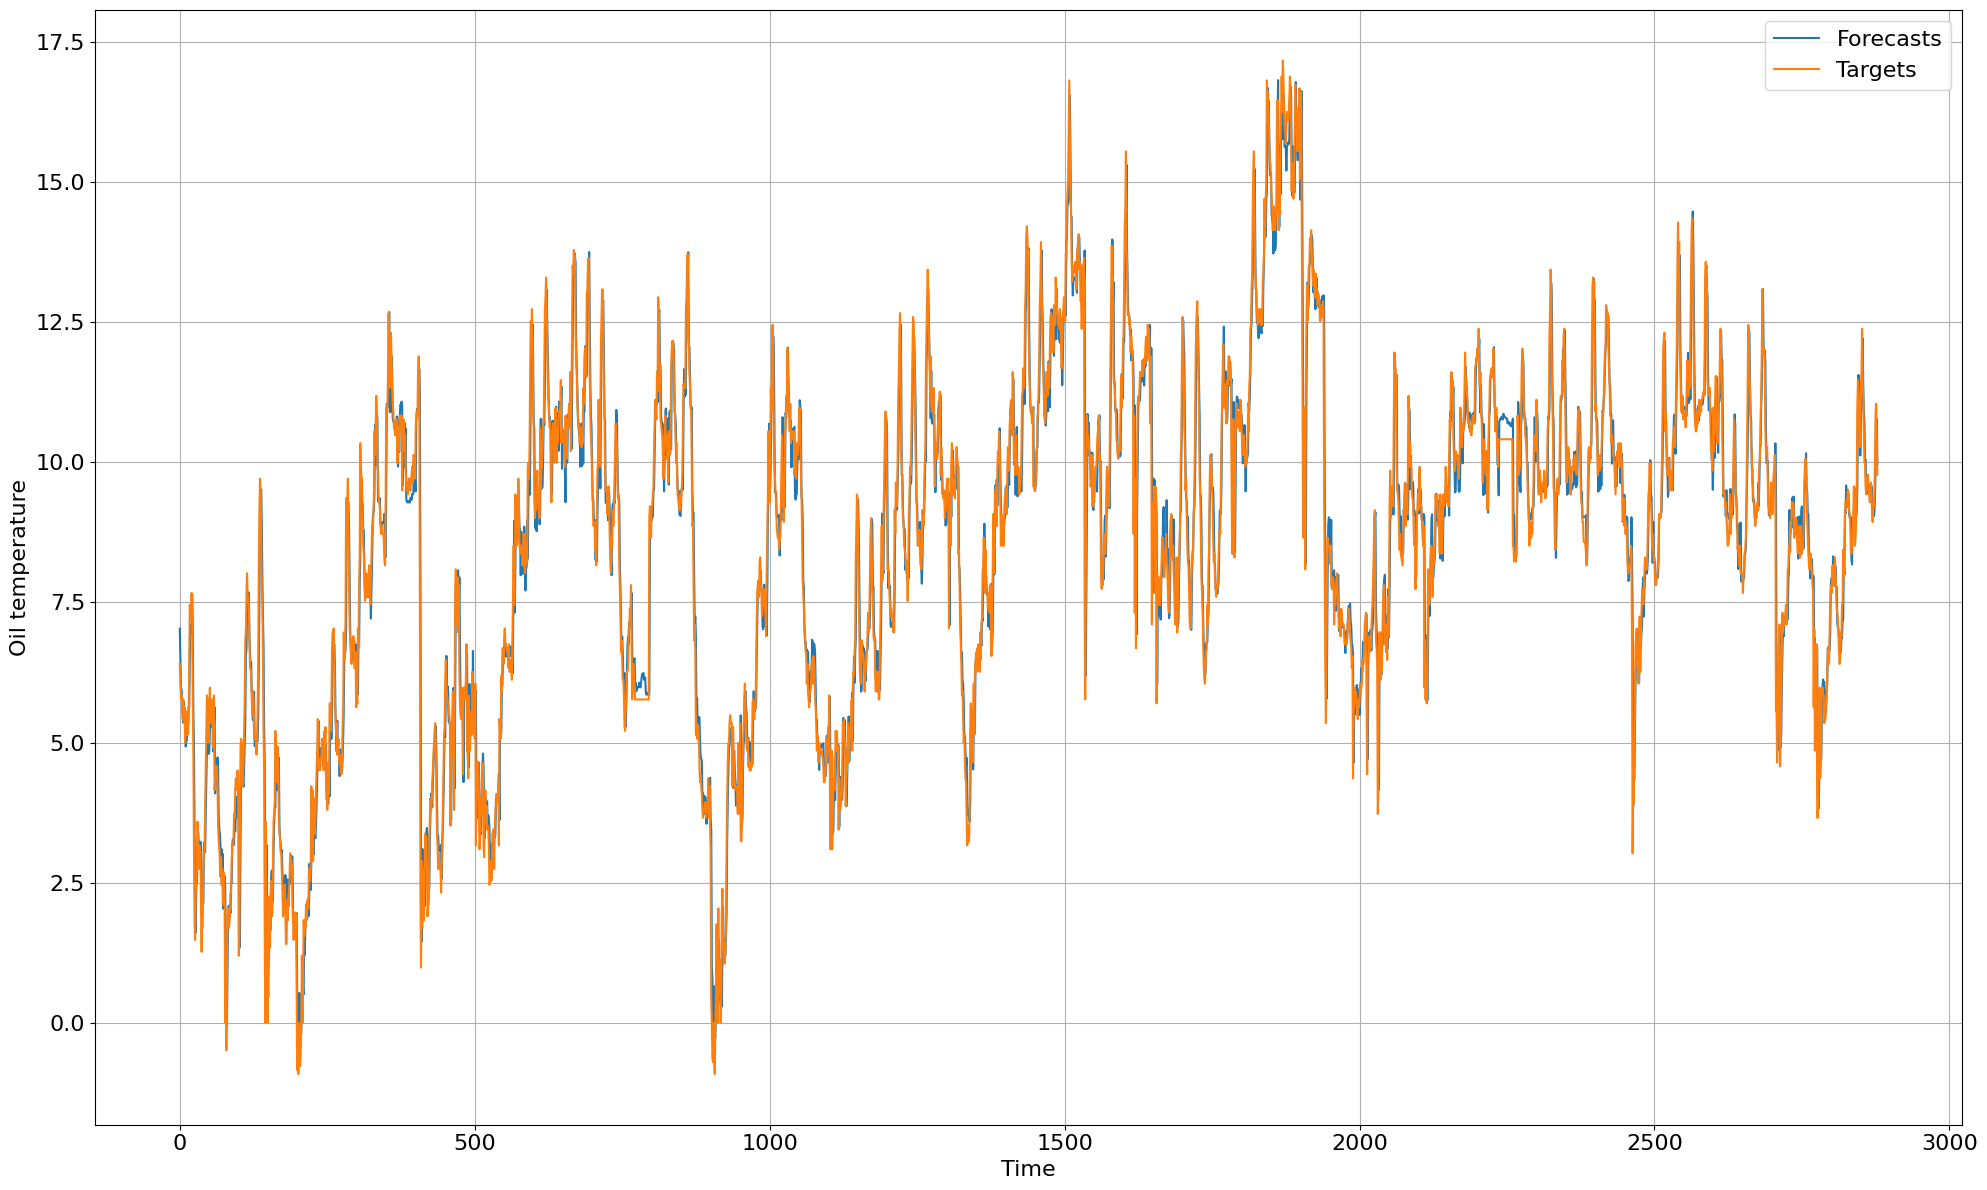

In [208]:
fontsize = 16
plot_df = pd.DataFrame({"Forecasts" : test_forecasts.flatten(), "Targets" : y_test.flatten()}, index=range(len(y_test.flatten())))

fig = plt.figure(figsize=(20,12))
plt.plot(plot_df.index, plot_df["Forecasts"], label="Forecasts")
plt.plot(plot_df.index, plot_df["Targets"], label="Targets")

plt.xlabel('Time', fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.ylabel("Oil temperature", fontsize=fontsize)
plt.grid(True)
plt.legend(fontsize=fontsize)
plt.tight_layout()